In [21]:
import sys
sys.path.append('..')
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging
from datetime import datetime
import copy
import os

import matplotlib.pyplot as plt
from matplotlib import colors

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

In [22]:
ARC_COLORS = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40',
    '#FFDC00', '#AAAAAA', '#F012BE', '#FF851B',
    '#7FDBFF', '#870C25'
]

cmap = colors.ListedColormap(ARC_COLORS)
norm = colors.BoundaryNorm(range(11), cmap.N)

In [23]:
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()

def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()

def grid_to_string(grid):
    if hasattr(grid, 'cpu'):
        grid = grid.cpu().numpy()
    return '\n'.join(' '.join(str(int(cell)) for cell in row) for row in grid)

In [24]:
def show_triplet(input_grid, gt_grid, pred_grid, title=""):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [25]:
def save_triplet(input_grid, gt_grid, pred_grid, save_path, title):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

In [26]:
def safe_tta(model, sx, sy, qx, steps=10, lr=5e-4):
    local_model = copy.deepcopy(model)
    local_model.train()

    params = list(local_model.decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)

    for _ in range(steps):
        optimizer.zero_grad()

        task_tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, task_tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        task_tokens = local_model.task_encoder(sx_feat, sy_feat)

        qx_feat = local_model.encoder(qx)
        return local_model.decoder(qx_feat, task_tokens)

In [30]:
MODEL_PATH = "/home/saij/ml/arc-meta/models/arc_epoch_200.pt"
DATA_DIR = "/home/saij/ml/arc-meta/data/evaluation"
BATCH_SIZE = 4
OUTPUT_DIR = "/home/saij/ml/arc-meta/logs"

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = os.path.join(OUTPUT_DIR, f"eval_{timestamp}")
img_dir = os.path.join(log_dir, "images")

os.makedirs(img_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(os.path.join(log_dir, "eval.log")),
        logging.StreamHandler()
    ]
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [31]:
dataset = ARCTaskDataset(DATA_DIR)
loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)

model = ARCModel().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

if isinstance(state_dict, dict) and any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError as e:
    print(f"Warning: strict load failed: {e}")
    incompatible = model.load_state_dict(state_dict, strict=False)
    print(
        f"Loaded with strict=False | missing_keys={len(incompatible.missing_keys)} "
        f"unexpected_keys={len(incompatible.unexpected_keys)}"
    )

model.eval()

ARCModel(
  (encoder): GridEncoder(
    (embed): Embedding(10, 128)
    (conv): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (task_encoder): TaskEncoder(
    (proj): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Decoder(
    (pre_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (cross_attn): CrossAttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  

  0%|          | 0/100 [00:00<?, ?it/s]


Task 1 | Sample 0
Pixel Acc: 0.9433 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 3 8 8 8 3 8 3 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 3 3 3 8 8 8 3 3 3 0 0 8 8 8 8 8 8 3 3 8 8 0 0 0 0 0 0 0
0 8 8 3 8 8 8 8 8 3 8 0 0 3 8 8 3 8 8 8 8 8 8 0 0 0 0 0 0 0
0 8 3 8 8 8 3 8 3 8 8 0 0 8 8 3 3 3 8 8 8 3 8 0 0 0 0 0 0 0
0 8 8 8 8 3 3 3 8 8 3 0 0 8 8 8 3 8 8 8 8 8 8 0 0 0 0 0 0 0
0 3 3 8 8 8 3 8 8 8 8 0 0 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0
0 8 8 8 8 8 8 8 8 3 8 0 0 8 8 8 3 8 8 3 8 8 8 0 0 0 0 0 0 0
0 3 8 8 3 8 8 8 3 8 8 0 0 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 8 3 8 8 8 8 8 8 3 8 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
3 8 8 8 8 8 3 8 8 8 0 0 3 3 8 8 3 8 8 8 3 8 0 0 0 0 0 0 0 0
8 8 3 8 8 3 3 3 8 8 0 0 8 8 8 3 3 3 8 8 8 3 0 0 0 0 0 0 0 0
8 3 3 3 8 8 3 8 3 8 0 0 3 8 8 8 3 8 8 8 8 8 0 0 0 0 0 0 0 0
8 8 3 8 8 8 8 3 3 3 0 0 8 3 8 8 8 8

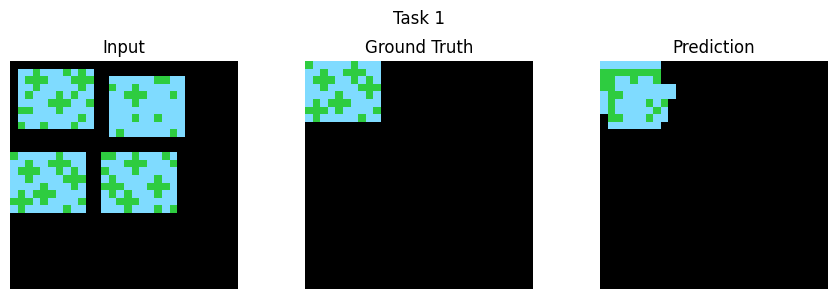


Task 2 | Sample 0
Pixel Acc: 0.7367 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 3 3 3 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 3 3 3 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 3 6 6 6 6 6 6 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 3 6 1 1 1 1 6 3 3 0 0 5 5 5 5 5 5 0 0 0 0 0 0 0 0 0 0 0
0 3 3 6 1 4 4 1 6 3 3 0 0 5 4 4 4 4 5 0 0 0 0 0 0 0 0 0 0 0
0 3 3 6 1 1 1 1 6 3 3 0 0 5 4 8 8 4 5 0 0 0 0 0 0 0 0 0 0 0
0 3 3 6 6 6 6 6 6 3 3 0 0 5 4 8 8 4 5 0 0 0 0 0 0 0 0 0 0 0
0 3 3 3 3 3 3 3 3 3 3 0 0 5 4 4 4 4 5 0 0 0 0 0 0 0 0 0 0 0
0 3 3 3 3 3 3 3 3 3 3 0 0 5 5 5 5 5 5 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 6 6 6 6 6 6 6 6 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 6 8 8 8 8 8 8 8 8 8 8 8 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 6 8 2 2 2 2 2 2 2 2 2 8 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 6 8 2 4 4 4 4 4 4 4 2 8 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 6 8 2 4 3 3 3 3 3 4 2 8 6 0 0

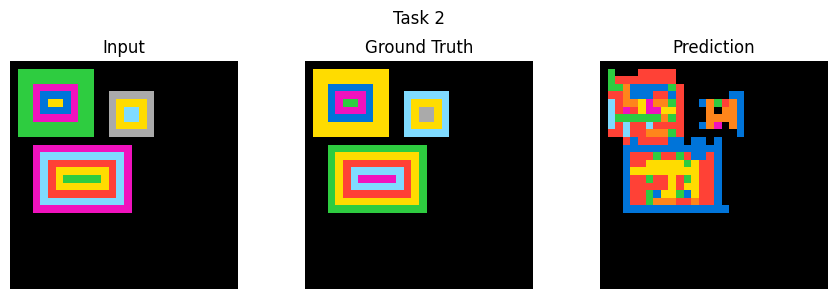


Task 3 | Sample 0
Pixel Acc: 0.9278 | Task Acc: 0.0000

Input:
 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
5 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

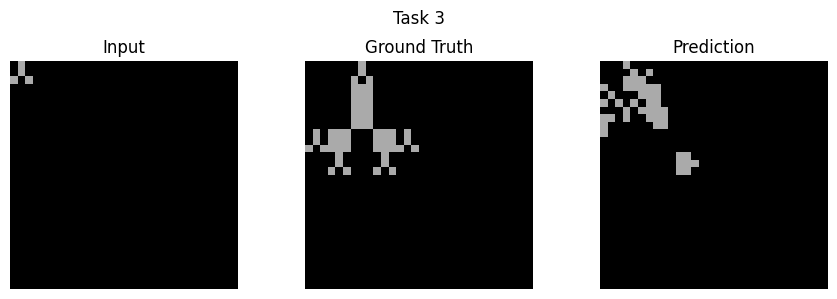


Task 4 | Sample 0
Pixel Acc: 0.9544 | Task Acc: 0.0000

Input:
 0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
6 6 6 6 6 2 6 7 6 6 4 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 1 1 1 1 2 1 7 1 1 4 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 8 8 8 8 8 8 7 8 8 4 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 0 0 2 0 7 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

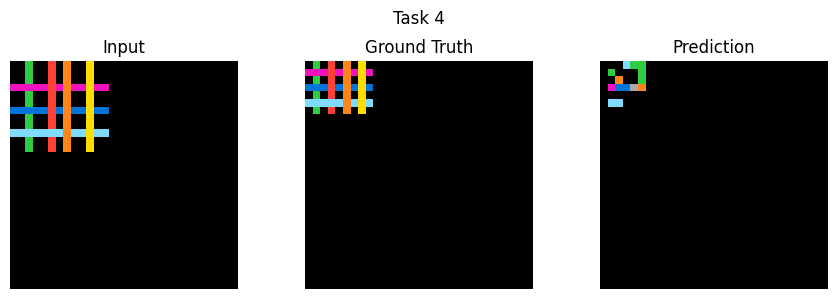

  1%|          | 1/100 [00:02<03:52,  2.35s/it]


Task 5 | Sample 0
Pixel Acc: 0.9856 | Task Acc: 0.0000

Input:
 7 7 0 0 4 0 9 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 0 0 0 4 0 9 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 7 7 0 4 9 9 9 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 7 0 0 4 9 0 9 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 0 0 0 4 9 9 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
4 4 4 4 4 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 2 0 2 4 8 8 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 2 0 4 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 2 0 4 8 0 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 2 4 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 2 2 4 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

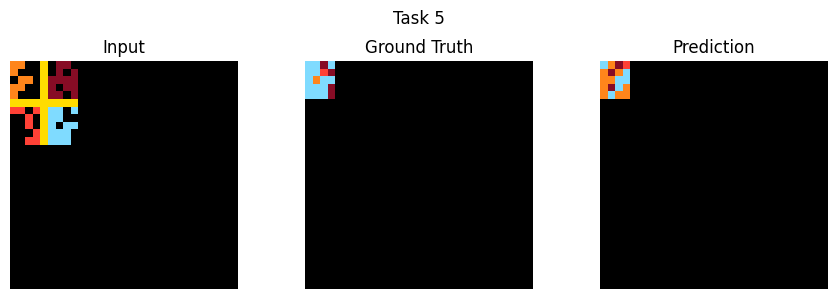


Task 6 | Sample 0
Pixel Acc: 0.9567 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 8 8 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 8 8 8 0 8 8 8 8 0 0 0 0
0 0 0 8 8 8 8 8 8 8 8 8 0 0 0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0
0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0
0 0 8 8 0 0 2 0 0 0 0 8 8 0 0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0
0 0 8 0 0 2 2 0 0 0 0 0 8 0 0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0
0 0 8 8 0 0 2 0 0 0 0 8 8 0 0 0 0 8 0 0 0 2 0 0 0 8 0 0 0 0
0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0 0 8 0 0 2 2 2 0 0 8 0 0 0 0
0 0 0 8 8 8 8 8 8 8 8 8 0 0 0 0 0 8 0 2 0 0 0 2 0 8 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 8 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 8 8 8 0 8 8 8 8 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 8 8 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 8 8 8 8 8 0 8 8 8 8 8 0

  2%|▏         | 2/100 [00:03<02:53,  1.77s/it]


Task 8 | Sample 0
Pixel Acc: 0.7578 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 2 2 2 2 2 2 2 0 0 0 1 0 0 3 3 3 3 3 3 0 1 0 0 0 0 0 0
0 0 0 2 0 0 0 0 0 2 2 2 0 0 0 0 3 0 0 0 0 3 0 0 0 0 0 0 0 0
0 0 0 2 0 6 0 0 8 0 0 2 0 0 0 0 3 0 0 6 0 3 0 0 0 0 0 0 0 0
0 0 0 2 0 0 1 0 0 0 0 2 0 0 3 3 3 0 0 0 0 3 0 0 0 0 0 0 0 0
0 2 2 2 0 0 0 0 0 0 1 2 0 0 3 0 0 0 0 8 0 3 0 0 0 0 0 0 0 0
0 2 0 0 1 0 6 0 0 0 0 2 0 0 3 8 0 0 0 0 0 3 0 0 0 0 0 0 0 0
0 2 0 0 0 0 0 2 2 2 2 2 0 0 3 0 0 0 8 0 0 3 0 0 0 0 0 0 0 0
0 2 0 0 0 0 0 2 0 0 0 0 0 0 3 0 0 0 0 1 0 3 0 0 0 0 0 0 0 0
0 2 2 2 2 2 2 2 0 0 0 0 0 0 3 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 1 0 0 3 3 3 3 0 0 0 3 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 8 0 3 0 0 0 0 0 0 0 0
0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 3 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 8 8 8 8 8 0 0 0 0 0 3 3 3 3 3 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 8 0 0 0 8 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 8 8 8 8 8 8 0 8 0 8 0 0 0 0 3 0

  3%|▎         | 3/100 [00:04<02:18,  1.43s/it]


Task 12 | Sample 0
Pixel Acc: 0.8689 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 3 8 3 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 0 0 0 0 0 3 4 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 3 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 3 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 3 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 3 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 3 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 

...

 98%|█████████▊| 98/100 [03:01<00:08,  4.36s/it]


Task 393 | Sample 0
Pixel Acc: 0.7500 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0

 99%|█████████▉| 99/100 [03:03<00:03,  3.53s/it]


Task 396 | Sample 0
Pixel Acc: 0.9978 | Task Acc: 0.0000

Input:
 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 1 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

100%|██████████| 100/100 [03:05<00:00,  1.85s/it]


In [32]:
total_pixel_acc = 0
total_task_acc = 0
count = 0

MAX_VIS = 5  # limit display

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(device)
    support_y = batch["support_y"].to(device)
    query_x = batch["query_x"].to(device)
    query_y = batch["query_y"].to(device)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len].long()
        sy = support_y[b, :s_len].long()
        qx = query_x[b, :q_len].long()
        qy = query_y[b, :q_len].long()

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        pred = safe_tta(model, sx, sy, qx)

        h, w = qy.shape[-2:]
        pred = pred[:, :, :h, :w]

        pred_classes = pred.argmax(dim=1)

        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel_acc += p_acc
        total_task_acc += t_acc
        count += 1

        for i in range(qx.shape[0]):

            print("\n" + "=" * 50)
            print(f"Task {count} | Sample {i}")
            print(f"Pixel Acc: {p_acc:.4f} | Task Acc: {t_acc:.4f}")

            print("\nInput:\n", grid_to_string(qx[i][0]))
            print("\nGT:\n", grid_to_string(qy[i][0]))
            print("\nPred:\n", grid_to_string(pred_classes[i]))

            # show inline
            if count <= MAX_VIS:
                show_triplet(
                    qx[i][0],
                    qy[i][0],
                    pred_classes[i],
                    title=f"Task {count}"
                )

            # save image
            save_path = os.path.join(
                img_dir,
                f"task_{count}_sample_{i}.png"
            )

            save_triplet(
                qx[i][0],
                qy[i][0],
                pred_classes[i],
                save_path,
                title=f"Task {count} | Pixel={p_acc:.3f}"
            )

In [ ]:
if count > 0:
    print("\n" + "=" * 50)
    print(f"Final Pixel Accuracy: {total_pixel_acc / count:.4f}")
    print(f"Final Task Accuracy:  {total_task_acc / count:.4f}")
    print("=" * 50)
else:
    print("No tasks evaluated.")


Final Pixel Accuracy: 0.9186
Final Task Accuracy:  0.0025


In [ ]:
import argparse
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging
from datetime import datetime
import copy

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel   # match your training


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()


# =========================
# SAFE TTA (FIXED)
# =========================
def safe_tta(model, sx, sy, qx, steps=10, lr=5e-4):
    local_model = copy.deepcopy(model)
    local_model.train()

    params = list(local_model.decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    # detach encoder features (CRITICAL FIX)
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)

    for _ in range(steps):
        optimizer.zero_grad()

        task_tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, task_tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        task_tokens = local_model.task_encoder(sx_feat, sy_feat)

        qx_feat = local_model.encoder(qx)
        return local_model.decoder(qx_feat, task_tokens)


# =========================
# Main
# =========================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--model_path", type=str, required=True)
    parser.add_argument("--data_dir", type=str, default="data/evaluation")
    parser.add_argument("--batch_size", type=int, default=4)
    args = parser.parse_args()

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.FileHandler(f"eval_fixed_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
            logging.StreamHandler()
        ]
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    logging.info(f"Device: {device}")

    dataset = ARCTaskDataset(args.data_dir)
    loader = get_arc_loader(dataset, batch_size=args.batch_size)

    model = ARCModel().to(device)

    model.load_state_dict(torch.load(args.model_path, map_location=device))
    model.eval()

    total_pixel_acc = 0
    total_task_acc = 0
    count = 0

    logging.info("Starting evaluation...")

    for batch in tqdm(loader):

        if batch["query_y"] is None:
            continue

        support_x = batch["support_x"].to(device)
        support_y = batch["support_y"].to(device)
        query_x = batch["query_x"].to(device)
        query_y = batch["query_y"].to(device)

        support_mask = batch["support_mask"]
        query_mask = batch["query_mask"]

        B = support_x.shape[0]

        for b in range(B):

            # ✅ SAFE slicing (NO boolean indexing)
            s_len = int(support_mask[b].sum().item())
            q_len = int(query_mask[b].sum().item())

            sx = support_x[b, :s_len].long()
            sy = support_y[b, :s_len].long()
            qx = query_x[b, :q_len].long()
            qy = query_y[b, :q_len].long()

            if sx.numel() == 0 or qx.numel() == 0:
                continue

            # =========================
            # SAFE TTA
            # =========================
            pred = safe_tta(model, sx, sy, qx)

            # =========================
            # CRITICAL: crop output
            # =========================
            h, w = qy.shape[-2:]
            pred = pred[:, :, :h, :w]

            # =========================
            # Metrics
            # =========================
            p_acc = pixel_accuracy(pred, qy)
            t_acc = task_accuracy(pred, qy)

            total_pixel_acc += p_acc
            total_task_acc += t_acc
            count += 1

            logging.info(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}")

    if count > 0:
        logging.info("=" * 50)
        logging.info(f"Pixel Accuracy: {total_pixel_acc / count:.4f}")
        logging.info(f"Task Accuracy:  {total_task_acc / count:.4f}")
        logging.info("=" * 50)
    else:
        logging.info("No tasks evaluated.")

In [ ]:
# =========================
# ARC EVAL WITH TTA (SINGLE CELL)
# =========================

import torch
import torch.nn.functional as F
from tqdm import tqdm
import copy
from pathlib import Path

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

# =========================
# CONFIG (EDIT HERE)
# =========================
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "models").exists() and (PROJECT_ROOT.parent / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_PATH = PROJECT_ROOT / "models" / "arc_best.pt"
DATA_DIR = PROJECT_ROOT / "data" / "evaluation"
BATCH_SIZE = 4

TTA_STEPS = 10
TTA_LR = 5e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()


# =========================
# TTA
# =========================
def safe_tta(model, sx, sy, qx, steps=TTA_STEPS, lr=TTA_LR):
    local_model = copy.deepcopy(model)
    local_model.train()

    optimizer = torch.optim.Adam(local_model.decoder.parameters(), lr=lr)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        qx_feat = local_model.encoder(qx)

    for _ in range(steps):
        optimizer.zero_grad()

        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(local_model.decoder.parameters(), 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(qx_feat, tokens)

    return pred
print(f"Device: {DEVICE}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Evaluation data directory not found: {DATA_DIR}")

dataset = ARCTaskDataset(str(DATA_DIR))
loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)

model = ARCModel().to(DEVICE)
model = ARCModel().to(DEVICE)
checkpoint = torch.load(str(MODEL_PATH), map_location=DEVICE)

# Support both raw state_dict and full training checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

# Handle DataParallel checkpoints if present
if isinstance(state_dict, dict) and any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError as e:
    print(f"Warning: strict load failed ({e}). Falling back to strict=False.")
    model.load_state_dict(state_dict, strict=False)

model.eval()
print(f"Loaded {len(dataset)} tasks")

# =========================
# Evaluation
# =========================
total_pixel_acc = 0
total_task_acc = 0
count = 0

print("\nStarting evaluation with TTA...\n")

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(DEVICE)
    support_y = batch["support_y"].to(DEVICE)
    query_x = batch["query_x"].to(DEVICE)
    query_y = batch["query_y"].to(DEVICE)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len]
        sy = support_y[b, :s_len]
        qx = query_x[b, :q_len]
        qy = query_y[b, :q_len]

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        # =========================
        # TTA
        # =========================
        pred = safe_tta(model, sx, sy, qx)

        # =========================
        # Crop
        # =========================
        h, w = qy.shape[-2:]
        pred = pred[:, :, :h, :w]

        # =========================
        # Metrics
        # =========================
        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel_acc += p_acc
        total_task_acc += t_acc
        count += 1

        print(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}")


# =========================
# Final Results
# =========================
print("\n" + "="*50)

if count > 0:
    print(f"Pixel Accuracy: {total_pixel_acc / count:.4f}")
    print(f"Task Accuracy:  {total_task_acc / count:.4f}")
else:
    print("No tasks evaluated.")

print("="*50)

Device: cuda
